In [31]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer
from tuned_lens.nn.lenses import TunedLens
from tuned_lens.plotting import PredictionTrajectory
from datasets import load_dataset
from tqdm.auto import tqdm
import logging

logging.basicConfig(level=logging.WARNING)

np.random.seed(42)
torch.manual_seed(42)

MODEL_NAME = "EleutherAI/pythia-160m-deduped"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [17]:
print(f"Loading model: {MODEL_NAME}")
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float32)
model.eval()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Model loaded successfully")

W_U = model.embed_out.weight.detach().cpu().float().numpy()
print(f"\nUnembedding matrix (embed_out) shape: {W_U.shape}")
print(f"  vocab_size : {W_U.shape[0]}")
print(f"  d_model    : {W_U.shape[1]}")
print(f"  size       : {W_U.nbytes / 1024**2:.1f} MB")

Loading model: EleutherAI/pythia-160m-deduped


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 472.33it/s, Materializing param=gpt_neox.layers.11.post_attention_layernorm.weight] 


Model loaded successfully

Unembedding matrix (embed_out) shape: (50304, 768)
  vocab_size : 50304
  d_model    : 768
  size       : 147.4 MB


In [18]:
from tuned_lens.nn.unembed import Unembed

# Sanity check: verify W_U matches what tuned_lens.nn.unembed.Unembed uses.
tl_unembed = Unembed(model)
tl_W_U = tl_unembed.unembedding.weight.detach().cpu().float().numpy()

assert tl_W_U.shape == W_U.shape, f"Shape mismatch: {tl_W_U.shape} vs {W_U.shape}"
assert np.allclose(tl_W_U, W_U), "Unembedding weights differ from tuned_lens!"
print("Sanity check passed: W_U matches tuned_lens Unembed.")

# Load tuned-lens probes for this model.
# Each probe Probe_l is a trained affine map R^d → R^d that approximates what
# the final-layer representation would look like if the model had stopped at layer l.
# tuned_lens.unembed is the same Unembed object (final LayerNorm + W_U).
tuned_lens = TunedLens.from_model_and_pretrained(model, map_location="cpu").float()
tuned_lens.eval()
print(f"TunedLens loaded  ({len(tuned_lens)} probes)")

Sanity check passed: W_U matches tuned_lens Unembed.
TunedLens loaded  (12 probes)


Rank of W_U: 753 / 768  (d_model = 768)
Computing reduced SVD of W_U (shape may take a moment)…
  U: (50304, 768),  S: (768,),  Vt: (768, 768)
  σ_max = 776.3987,  σ_min = 3.333676,  condition number = 232.9
  Relative Frobenius reconstruction error: 7.36e-07  (should be ~0)


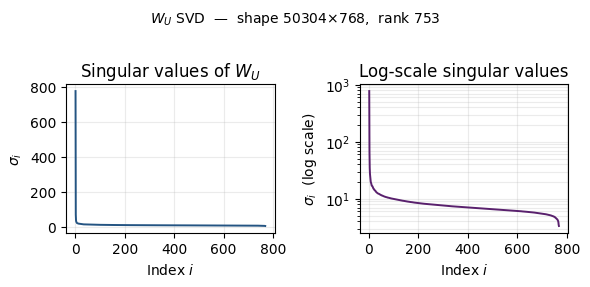

In [20]:
# ── Rank and reduced SVD of W_U ──────────────────────────────────────────────
#
# W_U ∈ R^(V × d)  where V = 50304 (vocab), d = 768 (d_model).
# Since V >> d, the rank r ≤ d. If r = d the row space is all of R^d.
#
# Reduced SVD:  W_U = U S Vt
#   U  : (V, r)  — left singular vectors (vocab directions)
#   S  : (r,)    — singular values in descending order
#   Vt : (r, d)  — right singular vectors; rows are an ONB for row(W_U)
#
# The ROW SPACE of W_U lives in R^d and is spanned by the rows of Vt.
# Projecting a hidden-state vector v ∈ R^d onto row(W_U):
#   v_proj = Vt.T @ (Vt @ v)   →   frac = ‖Vt v‖² / ‖v‖²

rank_W_U = np.linalg.matrix_rank(W_U)
print(f"Rank of W_U: {rank_W_U} / {W_U.shape[1]}  (d_model = {W_U.shape[1]})")

print("Computing reduced SVD of W_U (shape may take a moment)…")
U_svd, S_svd, Vt_svd = np.linalg.svd(W_U, full_matrices=False)
# shapes: U_svd (50304, 768), S_svd (768,), Vt_svd (768, 768)
assert U_svd.shape == (W_U.shape[0], rank_W_U) or U_svd.shape[1] == min(*W_U.shape)
print(f"  U: {U_svd.shape},  S: {S_svd.shape},  Vt: {Vt_svd.shape}")
print(f"  σ_max = {S_svd[0]:.4f},  σ_min = {S_svd[-1]:.6f},  "
      f"condition number = {S_svd[0]/S_svd[-1]:.1f}")

# Sanity check: first few singular values should reconstruct W_U approximately
recon_err = np.linalg.norm(W_U - (U_svd * S_svd) @ Vt_svd, 'fro') / np.linalg.norm(W_U, 'fro')
print(f"  Relative Frobenius reconstruction error: {recon_err:.2e}  (should be ~0)")

# ── Plot singular values ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(6, 2.8))

axes[0].plot(np.arange(1, len(S_svd) + 1), S_svd, lw=1.4, color="#245482")
axes[0].set_xlabel("Index $i$")
axes[0].set_ylabel("$\\sigma_i$")
axes[0].set_title("Singular values of $W_U$")
axes[0].grid(alpha=0.25)

axes[1].semilogy(np.arange(1, len(S_svd) + 1), S_svd, lw=1.4, color="#59206d")
axes[1].set_xlabel("Index $i$")
axes[1].set_ylabel("$\\sigma_i$  (log scale)")
axes[1].set_title("Log-scale singular values")
axes[1].grid(alpha=0.25, which="both")

fig.suptitle(f"$W_U$ SVD  —  shape {W_U.shape[0]}×{W_U.shape[1]},  rank {rank_W_U}",
             fontsize=10, y=1.01)
fig.tight_layout()
fig.savefig("embedding_svd_figures/svd_singular_values.pdf", dpi=200, bbox_inches="tight")
plt.show()


In [21]:
# ── Data loading — exact pipeline from affine_map_bootstrap.py ───────────────
#
# Each excerpt_*.npz contains:
#   hidden_states    : (N_LAYERS, seq_len, d_model)  — layer 0 = embedding
#   tl_top_token_ids : (N_LAYERS, seq_len)           — tuned-lens top-1 prediction per layer
#   input_ids        : (seq_len,)
#
# Stabilization layer for token t = earliest layer l such that the top-1
# prediction matches the final layer's top-1 for ALL layers l, l+1, …, L-1.
#
#   "easy"  (by_0)  : stabilization layer == 0  (correct from the very first layer)
#   "hard"  (never) : stabilization layer == N_LAYERS-1  (never fully stabilizes)
#
# We drop the last sequence position (no next-token target) and subsample the
# majority class to match the minority class, yielding balanced buckets.

DATA_ROOT  = Path("/Users/anjali/Library/CloudStorage/GoogleDrive-anjalisr@stanford.edu"
                  "/My Drive/depth_routing_data/token_evolution_data")
EXCERPT_DIR = DATA_ROOT / "excerpts"
N_LAYERS    = 13   # 1 embedding + 12 transformer blocks

def compute_stabilization_layer(top_ids: np.ndarray) -> np.ndarray:
    """Per-token index of earliest layer whose top-1 matches the final layer from then on."""
    matches_final = top_ids == top_ids[-1:]                          # (L, T) bool
    return np.argmax(np.cumprod(matches_final[::-1], axis=0)[::-1], axis=0)  # (T,)

def collect_tokens(category: str) -> np.ndarray:
    """
    Returns states array of shape (n_tokens, N_LAYERS, d_model) for the given category.
    category: 'easy' (stab==0) or 'hard' (stab==N_LAYERS-1)
    """
    stab_target = 0 if category == "easy" else (N_LAYERS - 1)
    excerpt_files = sorted(EXCERPT_DIR.glob("excerpt_*.npz"))
    if not excerpt_files:
        raise FileNotFoundError(f"No excerpt_*.npz files found in {EXCERPT_DIR}")

    chunks = []
    for fpath in tqdm(excerpt_files, desc=f"Loading '{category}'", leave=False):
        data       = np.load(fpath, allow_pickle=True)
        hs         = np.asarray(data["hidden_states"], dtype=np.float32)  # (L, T, d)
        top        = np.asarray(data["tl_top_token_ids"])                 # (L, T)

        top_work   = top[:, :-1]                          # drop last position
        stab       = compute_stabilization_layer(top_work)
        mask       = stab == stab_target
        if not mask.any():
            continue

        # Transpose to (T, L, d), then index matching tokens
        states = np.transpose(hs[:, :-1, :], (1, 0, 2))  # (T-1, L, d)
        chunks.append(states[mask])

    states_arr = np.concatenate(chunks).astype(np.float32)
    print(f"  {category:4s}: {len(states_arr):>7,} tokens,  shape {states_arr.shape}")
    return states_arr

easy_states = collect_tokens("easy")   # (n_easy, N_LAYERS, d_model)
hard_states = collect_tokens("hard")   # (n_hard, N_LAYERS, d_model)

# ── Balance: subsample majority class to minority class size ─────────────────
n_min = min(len(easy_states), len(hard_states))
minority_label = "easy" if len(easy_states) <= len(hard_states) else "hard"
print(f"\nMinority class: '{minority_label}' → subsampling both to {n_min:,} tokens")

rng = np.random.default_rng(42)
easy_states = easy_states[rng.choice(len(easy_states), n_min, replace=False)]
hard_states = hard_states[rng.choice(len(hard_states), n_min, replace=False)]

# ── Sanity checks ─────────────────────────────────────────────────────────────
assert len(easy_states) == len(hard_states) == n_min, "Class imbalance after subsampling!"
assert n_min < 15_000, f"Expected < 15K tokens per class, got {n_min}"
assert easy_states.shape[1] == N_LAYERS
assert np.all(np.isfinite(easy_states)) and np.all(np.isfinite(hard_states))
print(f"✓ Balanced: {n_min:,} tokens each  |  shape per bucket: {easy_states.shape}")


  easy:  14,353 tokens,  shape (14353, 13, 768)


  hard: 105,078 tokens,  shape (105078, 13, 768)

Minority class: 'easy' → subsampling both to 14,353 tokens
✓ Balanced: 14,353 tokens each  |  shape per bucket: (14353, 13, 768)


In [32]:
# ── Map raw hidden states to the tuned-lens final-layer representation ────────
#
# Raw hidden state h_l ∈ R^d is NOT yet in unembedding-ready space.
# The tuned-lens probe Probe_l : R^d → R^d is a trained affine map such that:
#
#   φ(h, l)  =  LayerNorm( Probe_l(h) )
#
# approximates the representation the model would produce at the final layer.
# This means  logits ≈ W_U @ φ(h, l)  —  φ(h, l) is "logit-ready".
#
# The final layer (l = 12) has no probe: it IS the final-layer space already,
# so Probe_12 = identity and we apply only the final LayerNorm.
#
# We then compute the change in this logit-ready representation across layers:
#
#   Δh'_l  =  φ(h_{l+1}, l+1) − φ(h_l, l)
#
# Projecting Δh' onto row(W_U) tells us how much of the change in the model's
# "intended output" is aligned with directions that actually affect logits.

def to_lens_space(states: np.ndarray) -> np.ndarray:
    """
    Apply the per-layer tuned-lens probe + final LayerNorm to every hidden state.
      φ(h, l) = LayerNorm( Probe_l(h) )      for l < len(tuned_lens)   [probe exists]
      φ(h, l) = LayerNorm( h )               for l = final layer       [identity probe]

    states  : (n_tokens, N_LAYERS, d_model)  —  raw hidden states
    returns : (n_tokens, N_LAYERS, d_model)  —  logit-ready lens representations
    """
    n_tokens, n_layers, d_model = states.shape
    out = np.empty_like(states)
    with torch.no_grad():
        for l in range(n_layers):
            h = torch.from_numpy(states[:, l, :])          # (n_tokens, d_model)
            if l < len(tuned_lens):
                h_t = tuned_lens.transform_hidden(h, l)    # Probe_l(h)  — affine map
                h_ln = tuned_lens.unembed.final_norm(h_t)      # LayerNorm(Probe_l(h))
            else:
                # h_t = h                                    # final layer: identity
                h_ln = h      # We already normed each layer when writing out the data, so the final layer already had the LayerNorm applied.
            out[:, l, :] = h_ln.cpu().float().numpy()
    return out

print("Mapping to lens space  φ(h, l) = LayerNorm(Probe_l(h))…")
easy_tl = to_lens_space(easy_states)   # (n_min, N_LAYERS, d_model)
hard_tl = to_lens_space(hard_states)   # (n_min, N_LAYERS, d_model)

assert easy_tl.shape == hard_tl.shape == easy_states.shape
assert np.all(np.isfinite(easy_tl)) and np.all(np.isfinite(hard_tl))
print(f"  ✓ shape: {easy_tl.shape}")

Mapping to lens space  φ(h, l) = LayerNorm(Probe_l(h))…
  ✓ shape: (14353, 13, 768)


In [23]:
len(tuned_lens)

12

Row-space basis V_r: (753, 768)  (rank=753)
  Orthonormality error of V_r: 8.34e-07  (should be ~0)

Computing projection fractions…
  easy  fracs: min=0.8095  max=0.9770
  hard  fracs: min=0.8131  max=0.9787


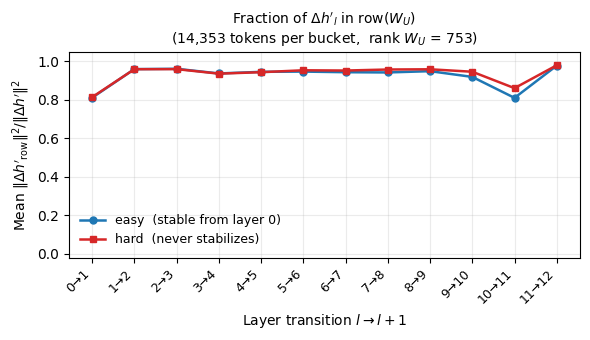

In [38]:
# ── Project Δh'_l onto the row space of W_U ────────────────────────────────────
#
# For each layer transition l → l+1:
#   1. Lens-space delta:
#        Δh'  =  φ(h_{l+1}, l+1) − φ(h_l, l)   ∈ R^d
#      where φ(h, l) = LayerNorm(Probe_l(h)) is the logit-ready representation.
#
#   2. Project Δh' onto row(W_U) using the orthonormal row basis V_r of Vt_svd:
#        Δh'_proj = V_r^T (V_r Δh')     [V_r : (r, d), orthonormal rows]
#
#   3. Projection fraction:
#        frac = ‖V_r Δh'‖² / ‖Δh'‖²  ∈ [0, 1]
#
#   frac < 1 means part of the lens-space update is in null(W_U) and cannot
#   affect logits; frac = 1 means the entire update is logit-visible.

# V_r: (r, d_model) — orthonormal basis for row(W_U)
V_r = Vt_svd[:rank_W_U]   # shape (rank_W_U, d_model)
print(f"Row-space basis V_r: {V_r.shape}  (rank={rank_W_U})")

ortho_err = np.max(np.abs(V_r @ V_r.T - np.eye(rank_W_U)))
print(f"  Orthonormality error of V_r: {ortho_err:.2e}  (should be ~0)")

def projection_fractions(states: np.ndarray) -> np.ndarray:
    """
    Mean fraction of ‖Δh'_l‖² lying in row(W_U) for each layer transition.

    states  : (n_tokens, N_LAYERS, d_model)  — lens-mapped representations φ(h, l)
    returns : (N_LAYERS-1,)
    """
    n_transitions = states.shape[1] - 1
    fracs = np.empty(n_transitions)
    for l in range(n_transitions):
        delta = states[:, l + 1, :] - states[:, l, :]      # Δh' = φ(h_{l+1},l+1) − φ(h_l,l)
        proj_coords   = delta @ V_r.T                        # (n, r)
        norm_sq_total = np.sum(delta       ** 2, axis=-1)   # ‖Δh'‖²
        norm_sq_proj  = np.sum(proj_coords ** 2, axis=-1)   # ‖V_r Δh'‖²
        valid = norm_sq_total > 1e-12
        fracs[l] = np.mean(norm_sq_proj[valid] / norm_sq_total[valid])
    return fracs

print("\nComputing projection fractions…")
easy_fracs = projection_fractions(easy_tl)
hard_fracs = projection_fractions(hard_tl)

assert np.all((easy_fracs >= 0) & (easy_fracs <= 1 + 1e-6)), "easy fracs out of range"
assert np.all((hard_fracs >= 0) & (hard_fracs <= 1 + 1e-6)), "hard fracs out of range"
print(f"  easy  fracs: min={easy_fracs.min():.4f}  max={easy_fracs.max():.4f}")
print(f"  hard  fracs: min={hard_fracs.min():.4f}  max={hard_fracs.max():.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
COLOR_EASY   = "tab:blue"
COLOR_HARD   = "tab:red"
n_trans      = N_LAYERS - 1
xtick_labels = [f"{l}→{l+1}" for l in range(n_trans)]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(n_trans), easy_fracs, "o-", color=COLOR_EASY, lw=1.8, ms=5,
        label="easy  (stable from layer 0)")
ax.plot(range(n_trans), hard_fracs, "s-", color=COLOR_HARD, lw=1.8, ms=5,
        label="hard  (never stabilizes)")

ax.set_xticks(range(n_trans))
ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=9)
ax.set_ylabel(r"Mean $\|\Delta h'_\mathrm{row}\|^2 / \|\Delta h'\|^2$",
              fontsize=10)
ax.set_xlabel("Layer transition $l \\to l+1$", fontsize=10)
ax.set_title(r"Fraction of $\Delta h'_l$ in $\mathrm{row}(W_U)$"
             f"\n({n_min:,} tokens per bucket,  rank $W_U$ = {rank_W_U})", fontsize=10)
ax.set_ylim(-0.02, 1.05)
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig("embedding_svd_figures/row_space_fractions.png", dpi=200, bbox_inches="tight")
plt.show()

Computing projection coordinates…
  coord arrays shape: (12, 14353, 753)  ✓
Isotropic baseline within row(W_U)  (n_dirs / rank_W_U):
  sv 1  (1 dir)                       0.1%
  sv 2–10  (9 dirs)                   1.2%
  sv 11–50  (40 dirs)                 5.3%
  sv 51–200  (150 dirs)               19.9%
  sv 201–753  (553 dirs)              73.4%


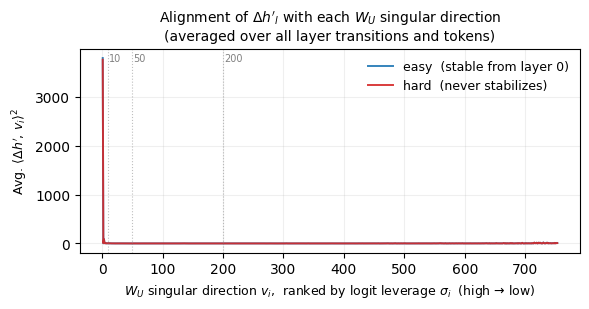

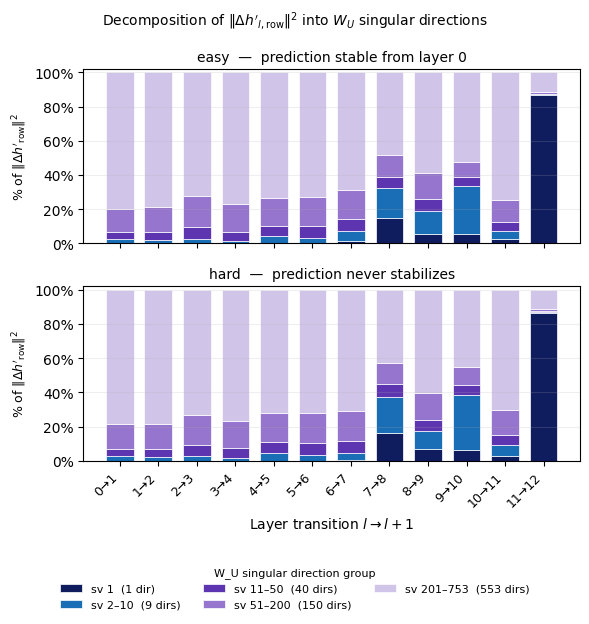

In [37]:
# ── Spectral decomposition of Δh' in the W_U row-space basis ──────────────────
#
# R^d = row(W_U) ⊕ null(W_U)
#   null(W_U) : directions W_U maps to 0  — Δh' here cannot affect logits
#   row(W_U)  : "logit-visible" subspace  — Δh' here changes the output distribution
#
# The right singular vectors v_i (rows of V_r) are orthonormal axes of row(W_U),
# ranked by logit leverage:
#   moving 1 unit along v_1 shifts logits by σ_1  (largest effect)
#   moving 1 unit along v_r shifts logits by σ_r  (smallest effect)
#
# For each transition, we project Δh' = φ(h_{l+1},l+1) − φ(h_l,l) onto row(W_U)
# and decompose its row-space component into coordinates <Δh', v_i>.
# The squared coefficient tells us how much of the logit-visible update
# points in each logit-leverage direction.
#
# Random (isotropic) baseline — within row(W_U), a random vector distributes
# uniformly, so each bucket's share equals (n_dirs_in_bucket / rank_W_U):

def _isotropic_baseline(sl):
    n = len(range(*sl.indices(rank_W_U)))
    return f"{100 * n / rank_W_U:.1f}%"

# ── Compute all projection coordinates ───────────────────────────────────────
def compute_all_coords(states: np.ndarray) -> np.ndarray:
    """
    For each layer transition l→l+1, compute <Δh'_l, v_i> for all row-space v_i.
      Δh'_l = φ(h_{l+1}, l+1) − φ(h_l, l)

    states  : (n_tokens, N_LAYERS, d_model)  — lens-mapped representations φ(h, l)
    returns : (N_LAYERS-1, n_tokens, rank_W_U)
              out[l, n, i] = <φ(h_{l+1},l+1) − φ(h_l,l),  v_i>
    """
    chunks = []
    for l in range(states.shape[1] - 1):
        delta = states[:, l + 1, :] - states[:, l, :]   # Δh' = φ(h_{l+1},l+1) − φ(h_l,l)
        chunks.append(delta @ V_r.T)                      # (n, rank_W_U)
    return np.stack(chunks, axis=0)                       # (n_trans, n, rank_W_U)

print("Computing projection coordinates…")
easy_coords = compute_all_coords(easy_tl)   # (12, n_min, rank_W_U)
hard_coords = compute_all_coords(hard_tl)   # (12, n_min, rank_W_U)

assert easy_coords.shape == hard_coords.shape == (N_LAYERS - 1, n_min, rank_W_U)
print(f"  coord arrays shape: {easy_coords.shape}  ✓")

# ── Average squared alignment per singular direction ─────────────────────────
# Mean over all tokens and layer transitions of <Δh', v_i>²
easy_spec = np.mean(easy_coords ** 2, axis=(0, 1))   # (rank_W_U,)
hard_spec = np.mean(hard_coords ** 2, axis=(0, 1))   # (rank_W_U,)

# ── Per-layer breakdown by sv bucket ─────────────────────────────────────────
SV_BUCKETS = [
    ("sv 1  (1 dir)",                                    slice(0, 1),      "#0f1c5e"),
    ("sv 2–10  (9 dirs)",                                slice(1, 10),     "#1a6eb5"),
    ("sv 11–50  (40 dirs)",                              slice(10, 50),    "#5e35b1"),
    ("sv 51–200  (150 dirs)",                            slice(50, 200),   "#9575cd"),
    (f"sv 201–{rank_W_U}  ({rank_W_U - 200} dirs)",     slice(200, None), "#d1c4e9"),
]

def bucket_energy_fracs(coords: np.ndarray) -> np.ndarray:
    """
    Share of ‖V_r Δh'‖² (row-space energy) falling in each sv bucket, per layer.

    coords  : (n_trans, n_tokens, rank_W_U)  — row-space coordinates of Δh'
    returns : (n_trans, n_buckets)  — rows sum to 1
    """
    energy = np.mean(coords ** 2, axis=1)           # (n_trans, rank_W_U): mean sq coord per dir
    total  = energy.sum(axis=1, keepdims=True)       # (n_trans, 1): total row-space energy
    return np.column_stack([
        energy[:, sl].sum(axis=1) / total[:, 0]
        for _, sl, _ in SV_BUCKETS
    ])                                               # (n_trans, n_buckets)

easy_bfracs = bucket_energy_fracs(easy_coords)   # (12, 5)
hard_bfracs = bucket_energy_fracs(hard_coords)   # (12, 5)

assert np.allclose(easy_bfracs.sum(axis=1), 1.0, atol=1e-5)
assert np.allclose(hard_bfracs.sum(axis=1), 1.0, atol=1e-5)

# Print isotropic baselines for reference
print("Isotropic baseline within row(W_U)  (n_dirs / rank_W_U):")
for label, sl, _ in SV_BUCKETS:
    print(f"  {label:<35s} {_isotropic_baseline(sl)}")

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 1: Average squared alignment per singular direction
# ═══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(np.arange(1, rank_W_U + 1), easy_spec,
        lw=1.4, color=COLOR_EASY, label="easy  (stable from layer 0)", alpha=0.9)
ax.plot(np.arange(1, rank_W_U + 1), hard_spec,
        lw=1.4, color=COLOR_HARD, label="hard  (never stabilizes)", alpha=0.9)

for boundary, lbl in [(10, "10"), (50, "50"), (200, "200")]:
    ax.axvline(boundary, ls=":", lw=0.8, color="grey", alpha=0.5)
    ax.text(boundary + 2, ax.get_ylim()[1] * 0.98, lbl, fontsize=7, color="grey", va="top")

ax.set_xlabel(r"$W_U$ singular direction $v_i$,  ranked by logit leverage $\sigma_i$  (high → low)",
              fontsize=9)
ax.set_ylabel(r"Avg. $\langle\Delta h',\, v_i\rangle^2$", fontsize=9)
ax.set_title(r"Alignment of $\Delta h'_l$ with each $W_U$ singular direction"
             "\n(averaged over all layer transitions and tokens)", fontsize=10)
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# PLOT 2: Stacked bar — share of ‖V_r Δh'‖² per sv bucket, per layer transition
# ═══════════════════════════════════════════════════════════════════════════════
x            = np.arange(N_LAYERS - 1)
xtick_labels = [f"{l}→{l+1}" for l in range(N_LAYERS - 1)]
bucket_labels = [label for label, _, _ in SV_BUCKETS]
bucket_colors = [color  for _, _, color in SV_BUCKETS]

fig, axes = plt.subplots(2, 1, figsize=(6, 5.5), sharex=True)
for ax, bfracs, title in zip(
    axes,
    [easy_bfracs, hard_bfracs],
    ["easy  —  prediction stable from layer 0",
     "hard  —  prediction never stabilizes"],
):
    bottom = np.zeros(len(x))
    for k, (label, color) in enumerate(zip(bucket_labels, bucket_colors)):
        ax.bar(x, bfracs[:, k], bottom=bottom, label=label,
               color=color, width=0.72, edgecolor="white", linewidth=0.5)
        bottom += bfracs[:, k]
    # y-axis: fraction of ‖V_r Δh'‖² (row-space energy), not ‖Δh'‖²
    ax.set_ylabel(r"% of $\|\Delta h'_{\mathrm{row}}\|^2$", fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, 1.02)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.grid(axis="y", alpha=0.2)

axes[1].set_xticks(x)
axes[1].set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=9)
axes[1].set_xlabel("Layer transition $l \\to l+1$", fontsize=10)
fig.suptitle(
    r"Decomposition of $\|\Delta h'_{l,\mathrm{row}}\|^2$ into $W_U$ singular directions",
    fontsize=10,
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center", bbox_to_anchor=(0.5, -0.13),
    ncol=3, frameon=False, fontsize=8,
    title="W_U singular direction group", title_fontsize=8,
)
fig.tight_layout()
fig.savefig("embedding_svd_figures/delta_h_translated_decomposition.png", dpi=200, bbox_inches="tight")
plt.show()

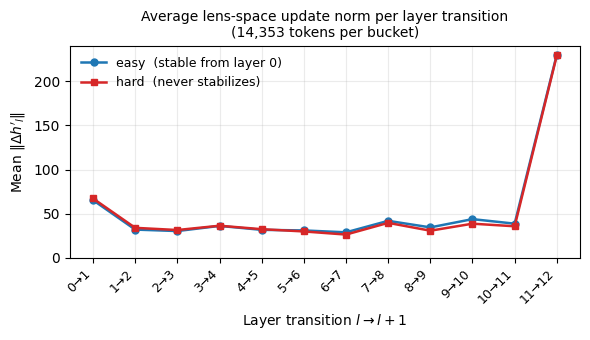

In [36]:
# ── Norm of Δh'_l by layer transition ─────────────────────────────────────────
n_trans      = N_LAYERS - 1
xtick_labels = [f"{l}→{l+1}" for l in range(n_trans)]

easy_norms = np.array([
    np.mean(np.linalg.norm(easy_tl[:, l+1, :] - easy_tl[:, l, :], axis=-1))
    for l in range(n_trans)
])
hard_norms = np.array([
    np.mean(np.linalg.norm(hard_tl[:, l+1, :] - hard_tl[:, l, :], axis=-1))
    for l in range(n_trans)
])

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(n_trans), easy_norms, "o-", color=COLOR_EASY, lw=1.8, ms=5,
        label="easy  (stable from layer 0)")
ax.plot(range(n_trans), hard_norms, "s-", color=COLOR_HARD, lw=1.8, ms=5,
        label="hard  (never stabilizes)")

ax.set_xticks(range(n_trans))
ax.set_xticklabels(xtick_labels, rotation=45, ha="right", fontsize=9)
ax.set_ylabel(r"Mean $\|\Delta h'_l\|$", fontsize=10)
ax.set_xlabel("Layer transition $l \\to l+1$", fontsize=10)
ax.set_title(f"Average lens-space update norm per layer transition\n"
             f"({n_min:,} tokens per bucket)", fontsize=10)
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig("embedding_svd_figures/hidden_state_norms.pdf", dpi=200, bbox_inches="tight")
plt.show()